# URBAN FLOOD STRESS | Infrastructure

Descarga y resume capas de infraestructura urbana relevantes para drenaje y respuesta hidrometeorológica en NYC.

Capas incluidas:
- catch basins
- green infrastructure
- outfalls

El notebook guarda los CSV crudos y los GeoPackages procesados en:
- `data/raw/infrastructure/`
- `data/processed/infrastructure/`


In [1]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from project_name.infrastructure import (
    INFRASTRUCTURE_DATASETS,
    download_infrastructure_layers,
)

RAW_DIR = ROOT / "data" / "raw" / "infrastructure"
PROCESSED_DIR = ROOT / "data" / "processed" / "infrastructure"
NYC_BOUNDARY_PATH = ROOT / "data" / "spatial" / "vector" / "nyc_borough_boundary" / "nybb.geojson"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


## Download

Ejecuta la descarga una sola vez si quieres refrescar los archivos desde Socrata.


In [2]:
summary = download_infrastructure_layers(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    app_token=os.getenv("NYC_APP_TOKEN"),
    limit=50_000,
)

summary_path = Path(summary.attrs["summary_path"])
display(summary)
print(f"Summary saved: {summary_path}")


,layer_name,dataset_id,raw_path,processed_path,raw_rows,geometry_status,geometry_rows
0,catch_basins,2w2g-fk3i,/home/map10194/Documents/urban-flood-stress/da...,/home/map10194/Documents/urban-flood-stress/da...,154212,saved,154212
1,green_infrastructure,df32-vzax,/home/map10194/Documents/urban-flood-stress/da...,/home/map10194/Documents/urban-flood-stress/da...,14335,not_detected,0
2,outfalls,8rjn-kpsh,/home/map10194/Documents/urban-flood-stress/da...,/home/map10194/Documents/urban-flood-stress/da...,5428,saved,5428


Summary saved: /home/map10194/Documents/urban-flood-stress/data/processed/infrastructure/infrastructure_download_summary.csv


## Overview

Visualiza las capas procesadas sobre el contorno de NYC cuando existe geometría puntual.


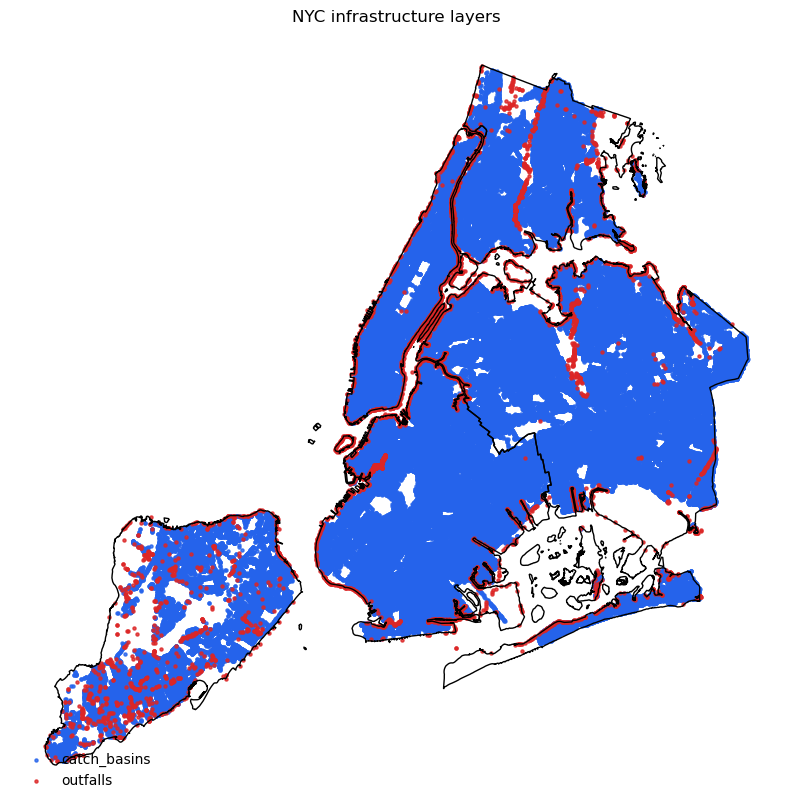

In [3]:
boundary = gpd.read_file(NYC_BOUNDARY_PATH).to_crs("EPSG:4326")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
boundary.boundary.plot(ax=ax, color="black", linewidth=1)

colors = {
    "catch_basins": "#2563eb",
    "green_infrastructure": "#16a34a",
    "outfalls": "#dc2626",
}

for _, row in summary.iterrows():
    if row["geometry_status"] != "saved":
        continue
    gdf = gpd.read_file(row["processed_path"])
    if gdf.empty:
        continue
    gdf.plot(ax=ax, color=colors.get(row["layer_name"], "#6b7280"), markersize=5, alpha=0.8, label=row["layer_name"])

ax.set_title("NYC infrastructure layers")
ax.set_axis_off()
ax.legend(frameon=False, loc="lower left")
plt.show()


## Uso

- Si quieres correrlo como script, usa `scripts/download_infrastructure.py`.
- Si alguna capa no trae coordenadas válidas, el notebook la reporta en `geometry_status`.
- El resumen queda en `data/processed/infrastructure/infrastructure_download_summary.csv`.
